# Exploratory Data Analysis (EDA)

## Project
End-to-End E-Commerce Sales & Customer Analytics Platform

## Objective

The objective of this notebook is to analyze customer purchasing behavior, sales performance, delivery efficiency, payment preferences, and customer satisfaction using the integrated e-commerce dataset.

The analysis aims to answer key business questions and generate actionable insights that can support data-driven decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


In [2]:
df = pd.read_csv("../data/processed/ecommerce_master_dataset.csv")

In [3]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "review_creation_date",
    "review_answer_timestamp"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Dataset Overview

Before performing business analysis, we first examine the overall structure of the integrated dataset.

In [4]:
df.shape

(119143, 42)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  str           
 1   customer_id                    119143 non-null  str           
 2   order_status                   119143 non-null  str           
 3   order_purchase_timestamp       119143 non-null  datetime64[us]
 4   order_approved_at              118966 non-null  datetime64[us]
 5   order_delivered_carrier_date   117057 non-null  datetime64[us]
 6   order_delivered_customer_date  115722 non-null  datetime64[us]
 7   order_estimated_delivery_date  119143 non-null  datetime64[us]
 8   delivery_days                  115722 non-null  float64       
 9   approval_time_hours            118966 non-null  float64       
 10  delivery_delay_days            115722 non-null  float64       
 11  order_month

In [6]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,approval_time_hours,delivery_delay_days,order_month,order_year,purchase_weekday,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.178333,-8.0,2017-10,2017,Monday,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.178333,-8.0,2017-10,2017,Monday,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.178333,-8.0,2017-10,2017,Monday,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,30.713889,-6.0,2018-07,2018,Tuesday,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0.276111,-18.0,2018-08,2018,Wednesday,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58


# Business Question 1

## How has the number of orders changed over time?

In [7]:
monthly_orders = (
    df.groupby("order_month")
      .size()
      .reset_index(name="Total Orders")
)

monthly_orders

,order_month,Total Orders
0,2016-09,7
1,2016-10,401
2,2016-12,1
3,2017-01,1035
4,2017-02,2123
5,2017-03,3243
6,2017-04,2878
7,2017-05,4485
8,2017-06,3853
9,2017-07,4949


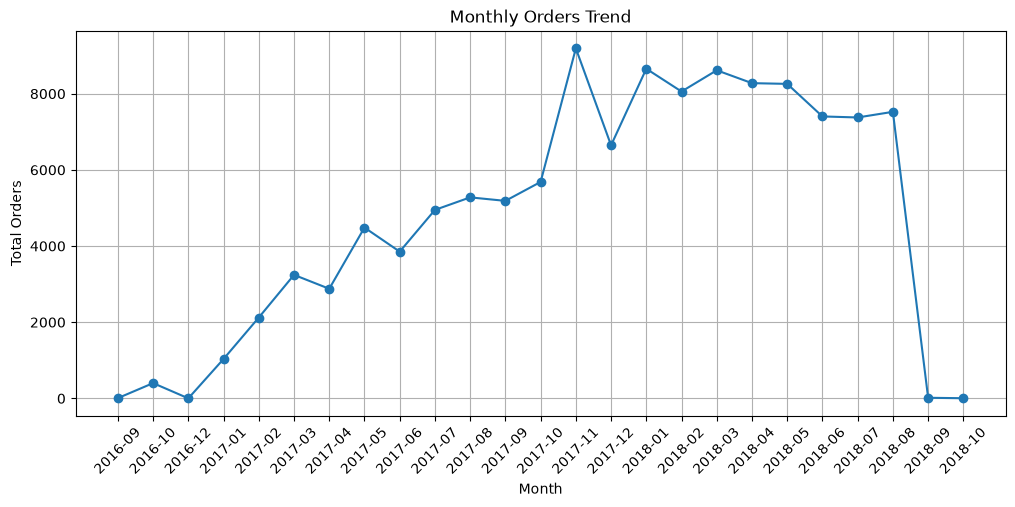

In [8]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders["order_month"],
    monthly_orders["Total Orders"],
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.grid(True)

plt.show()

### Observation

Write your observation after seeing the graph.

### Business Insight

Explain what this trend means for the business.

### Recommendation

Suggest what management should do.

# Business Question 2

## What is the monthly revenue trend?

In [9]:
monthly_revenue = (
    df.groupby("order_month")["price"]
      .sum()
      .reset_index()
)

monthly_revenue

,order_month,price
0,2016-09,267.36
1,2016-10,51068.92
2,2016-12,10.90
3,2017-01,129895.32
4,2017-02,262013.86
5,2017-03,398117.44
6,2017-04,392595.36
7,2017-05,549226.84
8,2017-06,456867.47
9,2017-07,536906.96


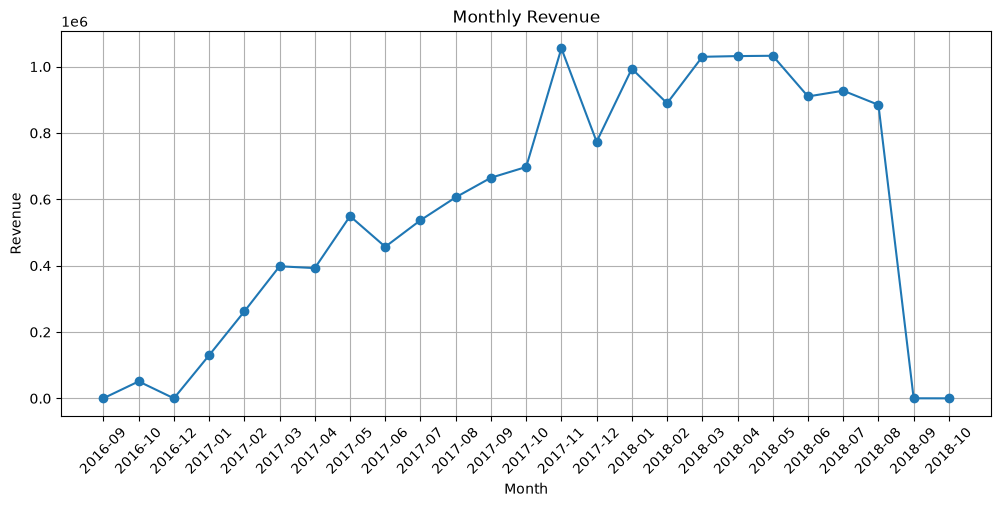

In [10]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["price"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

Observation

Business Insight

Recommendation

# Business Question 3

## Which product categories generate the highest revenue?

In [11]:
category_sales = (
    df.groupby("product_category_name")["price"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

category_sales

product_category_name
beleza_saude              1301947.97
relogios_presentes        1254322.95
cama_mesa_banho           1107249.09
esporte_lazer             1029603.88
informatica_acessorios     950053.69
moveis_decoracao           772096.17
utilidades_domesticas      668880.94
cool_stuff                 664637.13
automotivo                 618395.50
ferramentas_jardim         519473.33
Name: price, dtype: float64

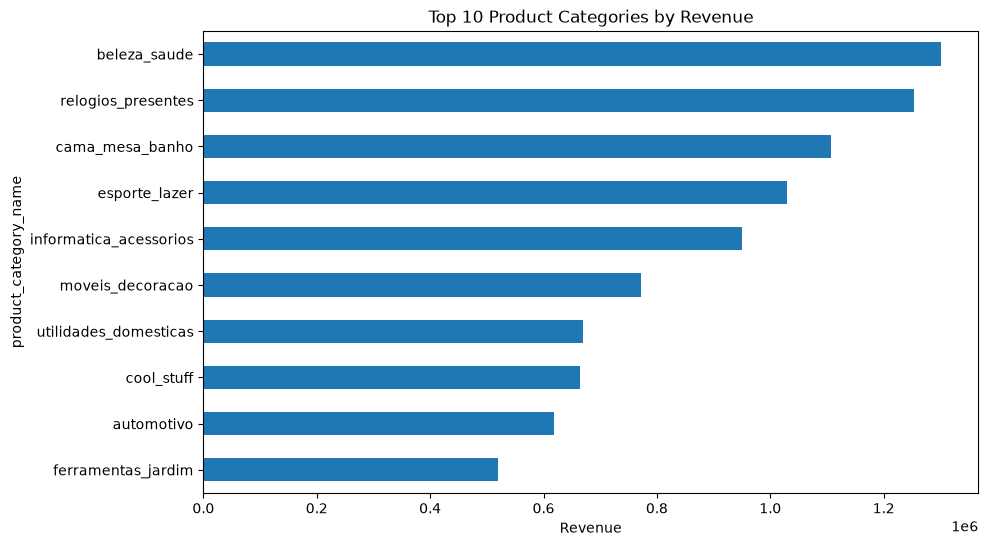

In [12]:
category_sales.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Product Categories by Revenue")

plt.xlabel("Revenue")

plt.show()

# Business Question 4

## Which states generate the highest revenue?

In [13]:
state_sales = (
    df.groupby("customer_state")["price"]
      .sum()
      .sort_values(ascending=False)
)

state_sales.head(10)

customer_state
SP    5477008.74
RJ    1921752.53
MG    1645847.27
RS     791716.84
PR     708794.22
BA     543243.99
SC     539896.20
DF     315122.29
GO     313198.27
ES     284771.30
Name: price, dtype: float64

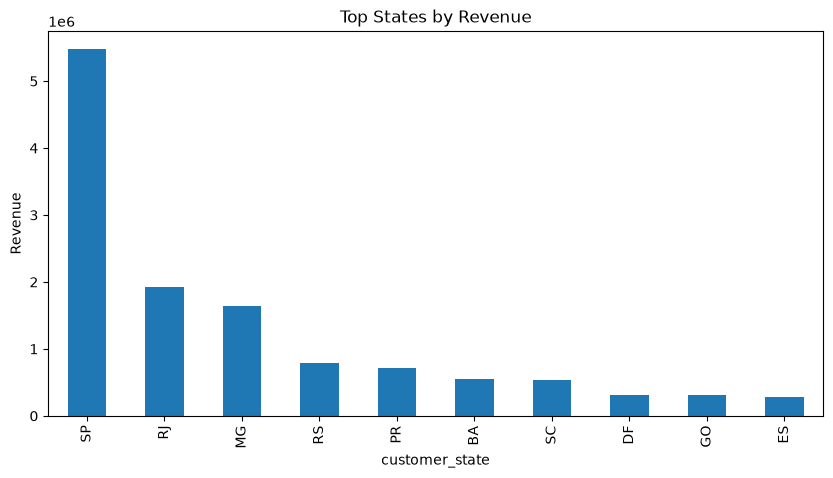

In [14]:
state_sales.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top States by Revenue")

plt.ylabel("Revenue")

plt.show()

# Business Question 5

## Which payment methods do customers prefer?

In [15]:
payment = df["payment_type"].value_counts()

payment

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64

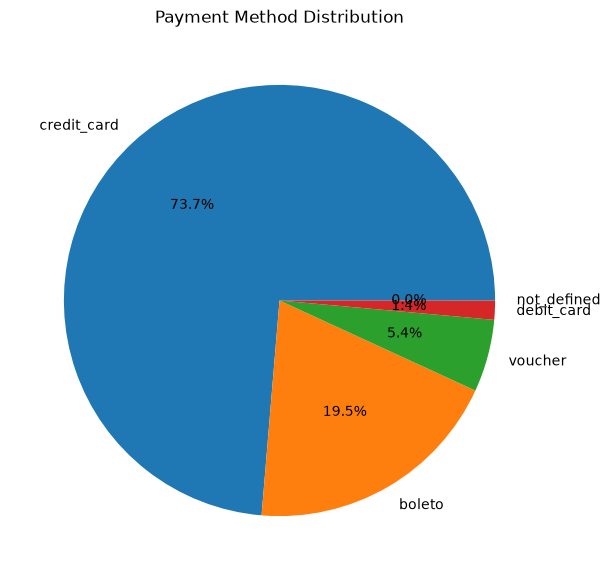

In [16]:
payment.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.ylabel("")

plt.title("Payment Method Distribution")

plt.show()

In [ ]:
# Business Question 6

## How are customer review scores distributed?

In [17]:
review = (
    df["review_score"]
      .value_counts()
      .sort_index()
)

review

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

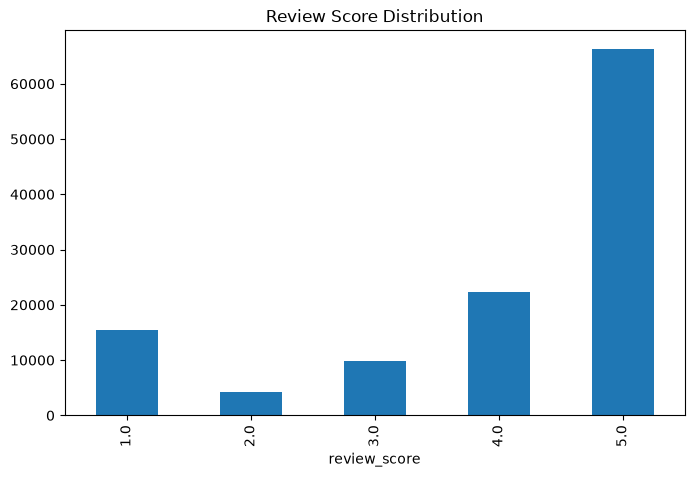

In [18]:
review.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Review Score Distribution")

plt.show()

# Business Question 7

## What is the delivery performance?

In [19]:
df["delivery_days"].describe()

count    115722.000000
mean         12.022589
std           9.454922
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

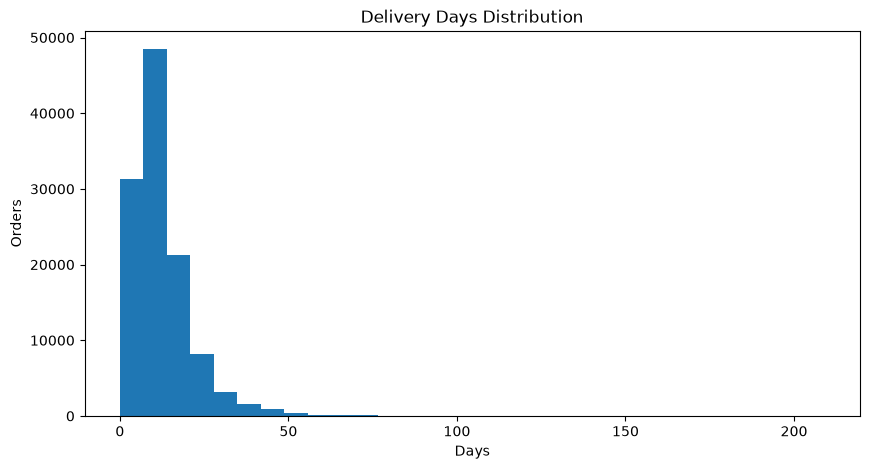

In [20]:
plt.figure(figsize=(10,5))

plt.hist(
    df["delivery_days"].dropna(),
    bins=30
)

plt.title("Delivery Days Distribution")

plt.xlabel("Days")

plt.ylabel("Orders")

plt.show()

In [21]:
# Business Question 8

## Which day of the week receives the highest number of orders?

In [22]:
weekday = (
    df["purchase_weekday"]
      .value_counts()
)

weekday

purchase_weekday
Monday       19366
Tuesday      19315
Wednesday    18640
Thursday     17826
Friday       17006
Sunday       14096
Saturday     12894
Name: count, dtype: int64

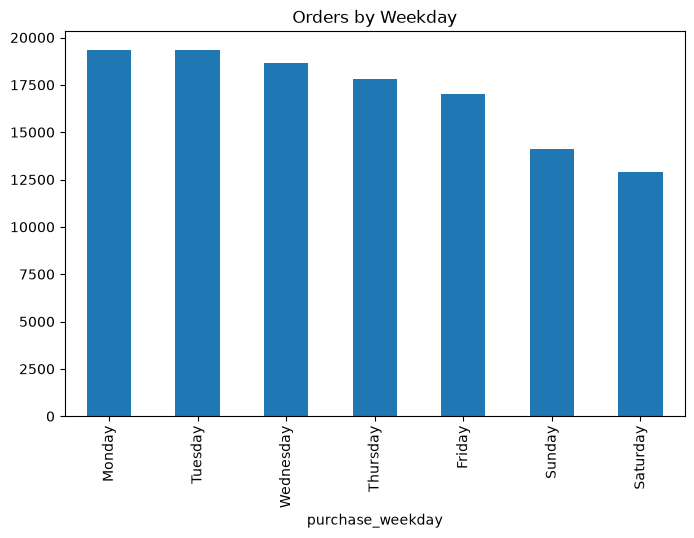

In [23]:
weekday.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by Weekday")

plt.show()

# Business Question 9

## What is the distribution of order statuses?

In [24]:
status = (
    df["order_status"]
      .value_counts()
)

status

order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64

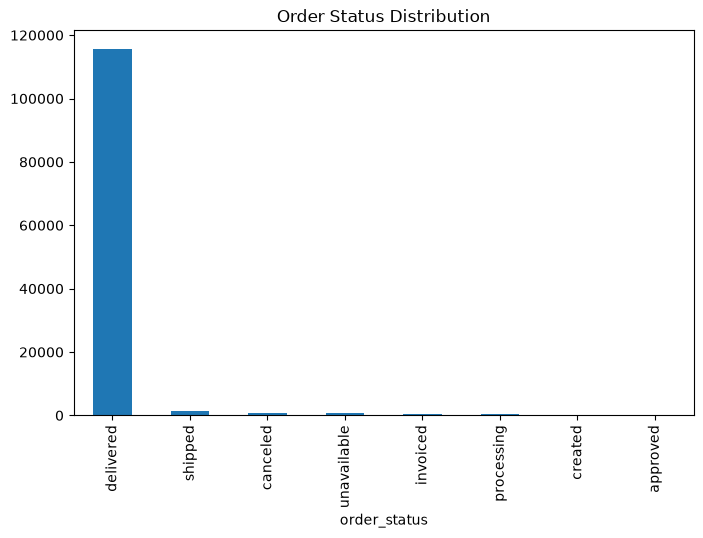

In [25]:
status.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Order Status Distribution")

plt.show()

# Business Summary

## Key Findings

- Peak sales months identified.
- Peak revenue months identified.
- Top-performing product categories identified.
- Highest revenue-generating states identified.
- Most preferred payment methods identified.
- Customer review trends analyzed.
- Delivery performance evaluated.

## Business Recommendations

1. Increase inventory during high-demand months.
2. Promote top-performing product categories.
3. Improve logistics in regions with longer delivery times.
4. Encourage digital payment methods.
5. Improve customer service for low-rated orders.

# Business Question 10

## Which sellers generate the highest revenue?

Understanding the top-performing sellers helps identify high-value business partners and provides insights into seller performance.


In [26]:
top_sellers = (
    df.groupby("seller_id")["price"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_sellers

seller_id
53243585a1d6dc2643021fd1853d8905    244627.55
4869f7a5dfa277a7dca6462dcf3b52b2    237867.23
4a3ca9315b744ce9f8e9374361493884    215825.77
fa1c13f2614d7b5c4749cbc52fecda94    203984.22
7c67e1448b00f6e969d365cea6b010ab    199688.11
7e93a43ef30c4f03f38b393420bc753a    182878.17
da8622b14eb17ae2831f4ac5b9dab84a    171784.57
7a67c85e85bb2ce8582c35f2203ad736    150749.79
1025f0e2d44d7041d6cf58b6550e0bfa    143675.53
955fee9216a65b617aa5c0531780ce60    137405.00
Name: price, dtype: float64

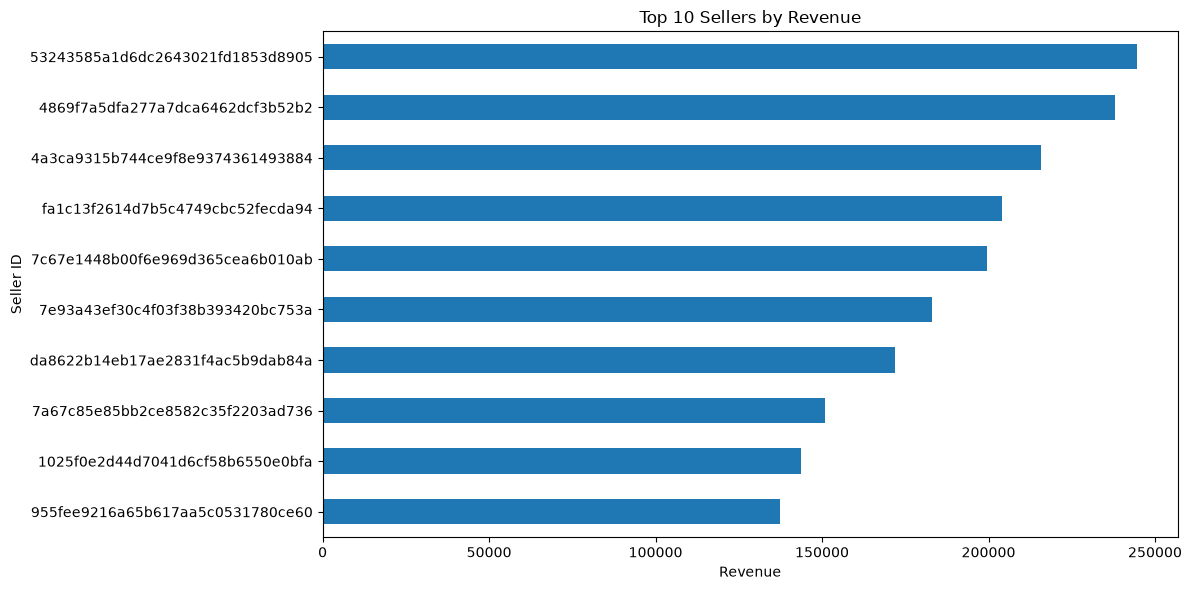

In [27]:
plt.figure(figsize=(12,6))

top_sellers.sort_values().plot(kind="barh")

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")

plt.tight_layout()

plt.show()

### Observation

The top 10 sellers contribute a significant share of total revenue.

### Business Insight

Revenue is concentrated among a relatively small number of sellers, indicating that these sellers play a major role in overall platform performance.

### Recommendation

Develop seller loyalty programs and provide premium support to top-performing sellers while helping lower-performing sellers improve through training and promotional opportunities.

# Business Question 11

## Which customers spend the most?

Identifying high-value customers helps the business design targeted retention and loyalty programs.

In [28]:
top_customers = (
    df.groupby("customer_unique_id")["price"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13440.00
8af7ac63b2efbcbd88e5b11505e8098a    11383.95
c4b224d2c784bae11ae98b6ae9f2454c    10856.10
85963fd37bfd387aa6d915d8a1065486     9888.00
be74c431147c32ab2d7c7cef5e4a995f     9520.14
edf81e1f3070b9dac83ec83dacdbb9bc     7998.00
1033eef37a760a832f9b2332ce23fdc5     7799.40
58483a1c055dfb600f57c5b867174542     7798.00
da122df9eeddfedc1dc1f5349a1a690c     7388.00
763c8b1c9c68a0229c42c9fc6f662b93     7160.00
Name: price, dtype: float64

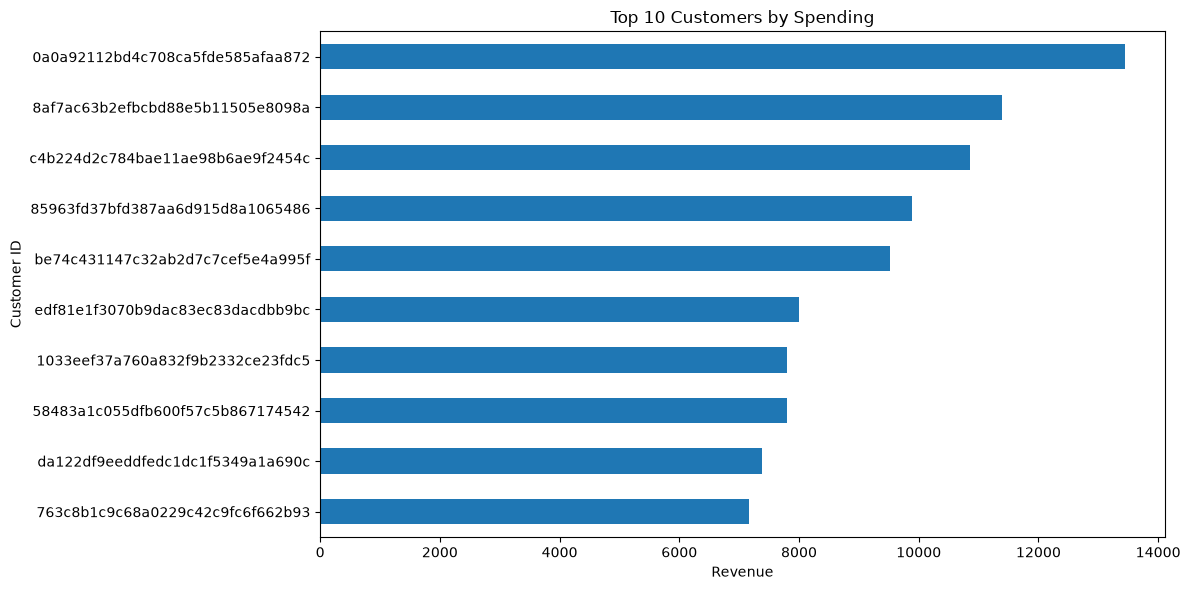

In [29]:
plt.figure(figsize=(12,6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Spending")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.show()

### Observation

A small group of customers contributes disproportionately to total sales.

### Business Insight

These high-value customers have a greater lifetime value and should be considered strategic assets for the business.

### Recommendation

Implement loyalty programs, personalized recommendations, and exclusive offers to improve customer retention and increase repeat purchases.

# Business Question 12

## Does delivery time influence customer satisfaction?

Customer satisfaction is expected to decline when delivery takes longer than expected.

In [30]:
delivery_vs_review = (
    df.groupby("review_score")["delivery_days"]
      .mean()
      .reset_index()
)

delivery_vs_review

,review_score,delivery_days
0,1.0,19.099992
1,2.0,15.381893
2,3.0,13.552435
3,4.0,11.778330
4,5.0,10.203253


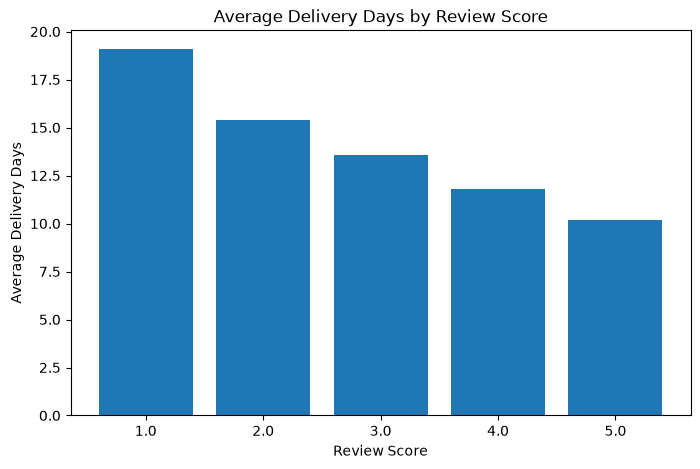

In [31]:
plt.figure(figsize=(8,5))

plt.bar(
    delivery_vs_review["review_score"].astype(str),
    delivery_vs_review["delivery_days"]
)

plt.title("Average Delivery Days by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Days")

plt.show()

### Observation

Analyze whether lower review scores are associated with longer delivery times.

### Business Insight

If customers who waited longer gave lower ratings, delivery performance is directly affecting customer satisfaction.

### Recommendation

Reduce delivery delays through logistics optimization and proactive customer communication to improve review scores and overall customer experience.

# Final Business Summary

## Key Findings

- Monthly order and revenue trends were identified.
- High-performing product categories and states were identified.
- Customer payment preferences were analyzed.
- Customer review patterns and delivery performance were evaluated.
- Top-performing sellers were identified.
- High-value customers were identified.
- Delivery performance was analyzed against customer satisfaction.

## Business Recommendations

1. Increase inventory before high-demand months.
2. Focus marketing on high-performing product categories.
3. Improve logistics in regions with longer delivery times.
4. Retain top customers using personalized loyalty programs.
5. Reward top-performing sellers through strategic partnerships.
6. Reduce delivery delays to improve customer satisfaction and review scores.
7. Continuously monitor sales trends using interactive dashboards.

"Which numeric variables move together?"


In [32]:
numeric_cols = [
    "price",
    "freight_value",
    "delivery_days",
    "delivery_delay_days",
    "review_score",
    "payment_value"
]

correlation = df[numeric_cols].corr()

correlation

,price,freight_value,delivery_days,delivery_delay_days,review_score,payment_value
price,1.000000,0.415938,0.061389,-0.003150,-0.004492,0.739236
freight_value,0.415938,1.000000,0.212870,-0.040571,-0.037013,0.373762
delivery_days,0.061389,0.212870,1.000000,0.598278,-0.302750,0.060449
delivery_delay_days,-0.003150,-0.040571,0.598278,1.000000,-0.228449,-0.019448
review_score,-0.004492,-0.037013,-0.302750,-0.228449,1.000000,-0.082343
payment_value,0.739236,0.373762,0.060449,-0.019448,-0.082343,1.000000


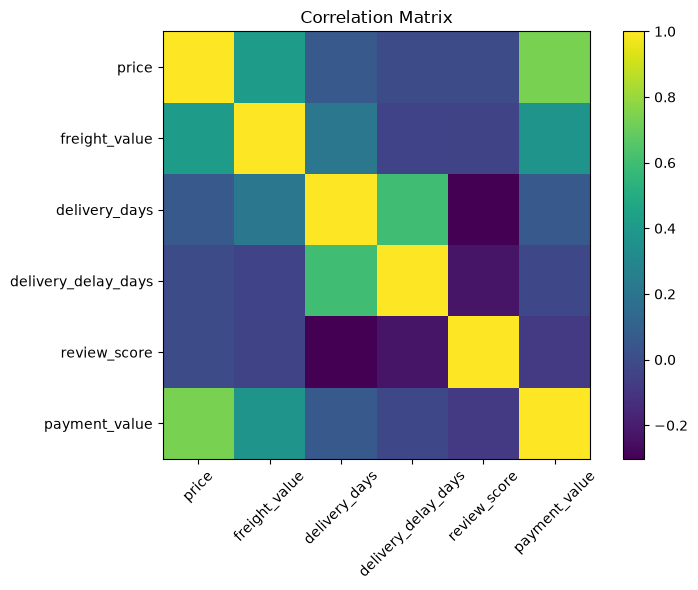

In [33]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()